Inspiration

Get your feet wet with regression techniques here on Kaggle by using this dataset. Perfect for beginners since the OpenIntro Statistics book does a good explanation in Chapter 8.

* Can we use total length to predict a possum's head length?
* Which possum body dimensions are most correlated with age and sex?
* Can we classify a possum's sex by its body dimensions and location?
* Can we predict a possum's trapping location from its body dimensions?


First, import dataset from Kaggle

In [81]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
#plt.style.use('ggplot')

In [83]:
df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abrambeyer/openintro-possum",
    "possum.csv"
)

Using Colab cache for faster access to the 'openintro-possum' dataset.


In [89]:
print("Initial data examination")
print("------------------------")

print("Head:")
print(df.head())

print()
print("Total cases =", df.shape[0])

print()
print("Data types:")
print(df.dtypes)

Initial data examination
------------------------
Head:
   case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
0     1     1  Vic   m  8.0     94.1    60.4      89.0   36.0      74.5   
1     2     1  Vic   f  6.0     92.5    57.6      91.5   36.5      72.5   
2     3     1  Vic   f  6.0     94.0    60.0      95.5   39.0      75.4   
3     4     1  Vic   f  6.0     93.2    57.1      92.0   38.0      76.1   
4     5     1  Vic   f  2.0     91.5    56.3      85.5   36.0      71.0   

   earconch   eye  chest  belly  
0      54.5  15.2   28.0   36.0  
1      51.2  16.0   28.5   33.0  
2      51.9  15.5   30.0   34.0  
3      52.2  15.2   28.0   34.0  
4      53.2  15.1   28.5   33.0  

Total cases = 104

Data types:
case          int64
site          int64
Pop          object
sex          object
age         float64
hdlngth     float64
skullw      float64
totlngth    float64
taill       float64
footlgth    float64
earconch    float64
eye         float64
chest       float

Range of features
-----------------
Population (note 'other'='New South Wales'|'Queensland'): ['Vic' 'other']
Sex: ['m' 'f']


<Axes: >

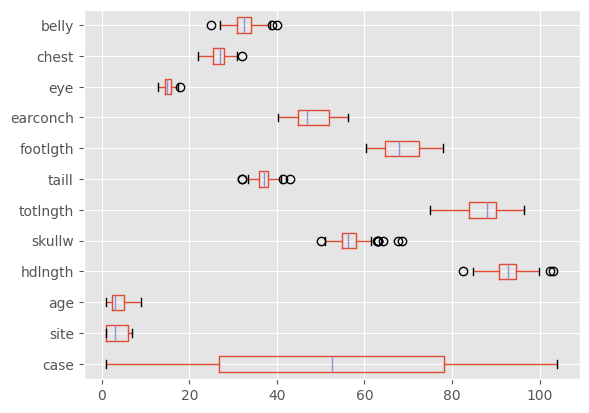

In [90]:
print("Range of features")
print("-----------------")

print("Population (note 'other'='New South Wales'|'Queensland'):", df['Pop'].unique())
print("Sex:", df['sex'].unique())

# matplotlib.pyplot.boxplot deprecates vert
# but it yells at me when I use orientation='horizontal'
df.boxplot(vert=False)

In [95]:
print("Null/NA values")
print("--------------")
na = df.isna()
print("Null values by feature:")
print(na.sum())

print()
print("Total null values =", na.sum().sum())

na_rows = na.any(axis='columns')
print("Total cases with null values =", na_rows.sum())

Null/NA values
--------------
Null values by feature:
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

Total null values = 3
Total cases with null values = 3


Since we have only 3/104 (= 2.89%) cases with null values, we choose to simply remove them.

In [101]:
df.dropna()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0
